# Lab 4
# Classification  

# <span style="color:red;">➡Data	Collection:</span> 

# Step 1: Import required libraries

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Step 2: Load the Dataset

In [2]:
# https://drive.google.com/file/d/1O8OmQlrQ2JwVph4steNqAQJNJlWYaXRy/view?usp=sharing
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


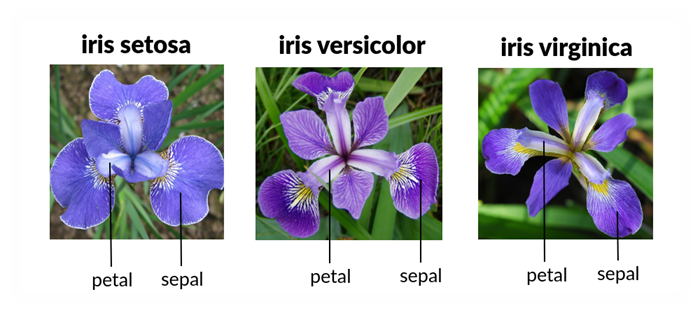

#  <span style="color:red;">➡Data Exploration:</span>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [6]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [7]:
df.shape

(150, 5)

In [9]:
# Count each category
counts = df['species'].value_counts()
counts

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
counts.index

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object', name='species')

In [11]:
counts.values

array([50, 50, 50])

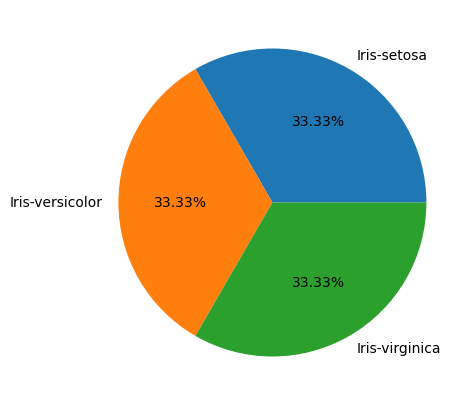

In [12]:
plt.figure(figsize=(7,5))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.2f%%',
)
plt.show()

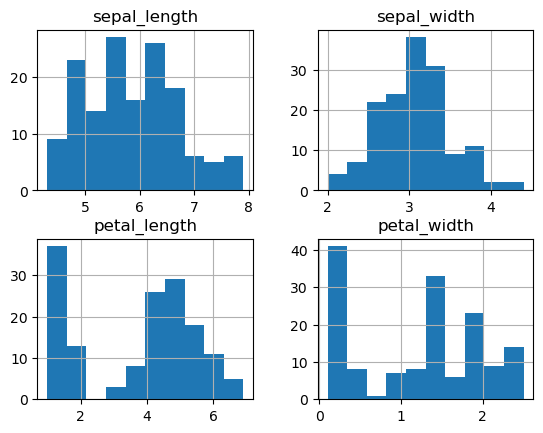

In [13]:
df.hist()
plt.show()

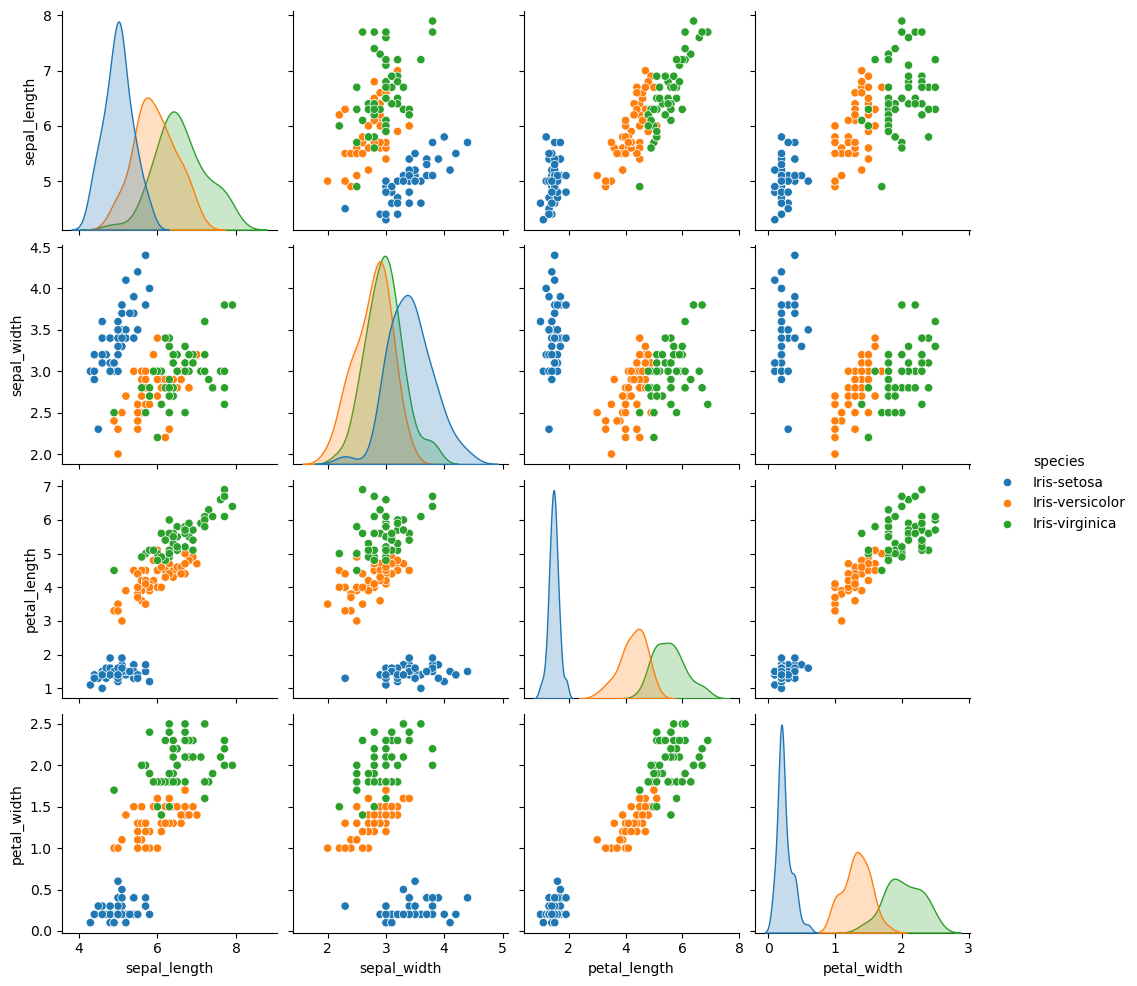

In [14]:
sns.pairplot(df,hue='species');

# <span style="color:red;">➡Data preprocessing</span> (data preparation and Cleaning)
## Handle	missing	values	and	duplicates,	remove	or	replace	outliers

# Step 1:Missing Values Handling:

In [15]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Step 2: Duplicate Handling.

In [16]:
df.duplicated().sum()

np.int64(3)

In [17]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Step 3: Outliers Handling

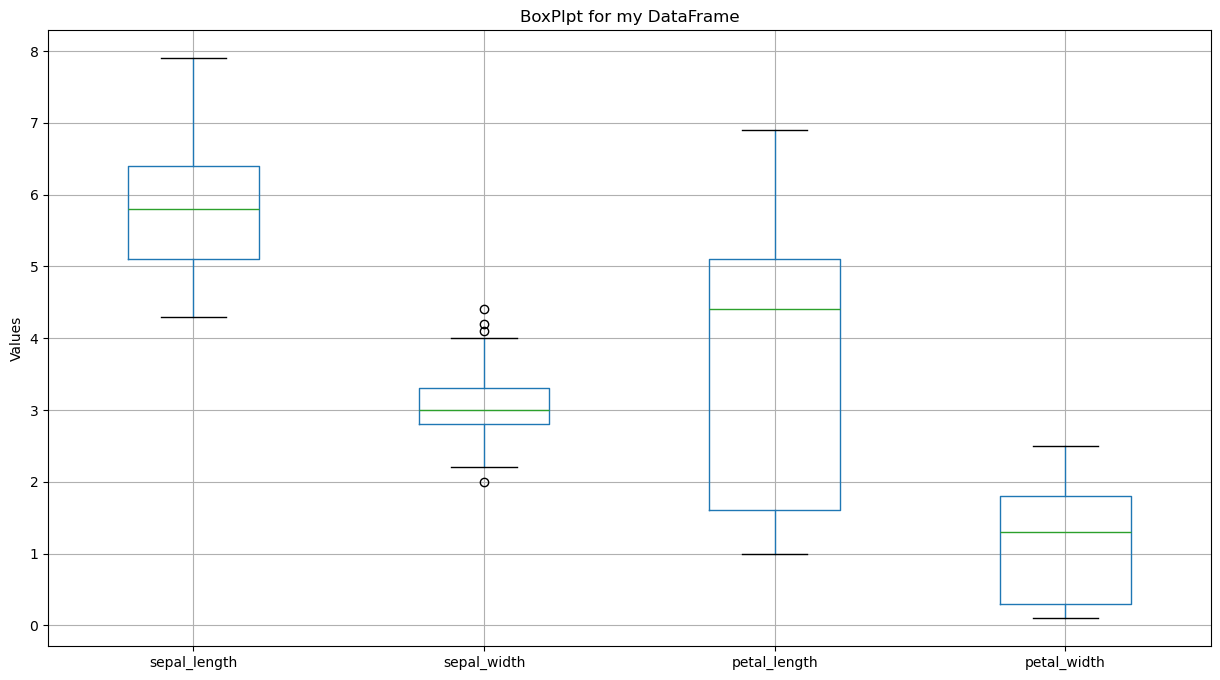

In [18]:
num_colmuns=df.select_dtypes(include=["float64","int64","int32"]).columns

plt.figure(figsize=(15,8))
df[num_colmuns].boxplot()
plt.title("BoxPlpt for my DataFrame")
plt.ylabel("Values")
plt.grid(True)
plt.show()


# <span style="color:red;">➡Label Encoder</span>

In machine learning, we usually deal with datasets which contains multiple labels in one or more than one columns. These labels can be in the form of words or numbers. Label Encoding refers to converting the labels into numeric form so as to convert it into the machine-readable form

In [19]:
# to convert categorical labels into numeric values
from sklearn.preprocessing import LabelEncoder

# Create an instance of the LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'species' categorical column
# Each unique category will be converted into a numerical value
df['species_encoded'] = label_encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [20]:
print(df['species'].unique())
print(df['species_encoded'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
[0 1 2]


# <span style="color:red;">➡Classification Model</span>

## 1) Define input features (X) and target variable (y)

In [21]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

# X = df.drop(columns=['species', 'species_encoded'])
# y = df['species_encoded']

## 2) Split the data into training and testing sets

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25
)

## 3) Applying Classification Models Using Multiple Algorithms

# 1. LogisticRegression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1) Build model
lr = LogisticRegression(max_iter=200)

# 2) Train
lr.fit(X_train, y_train)

# 3) Predict
y_pred_lr = lr.predict(X_test)

# 4) Evaluate 
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.972972972972973
Confusion Matrix:
 [[16  0  0]
 [ 0  8  1]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        12

    accuracy                           0.97        37
   macro avg       0.97      0.96      0.97        37
weighted avg       0.98      0.97      0.97        37



# 2. KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9459459459459459
Confusion Matrix:
 [[16  0  0]
 [ 0  7  2]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.78      0.88         9
           2       0.86      1.00      0.92        12

    accuracy                           0.95        37
   macro avg       0.95      0.93      0.93        37
weighted avg       0.95      0.95      0.94        37



# 3. DecisionTree

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9459459459459459
Confusion Matrix:
 [[16  0  0]
 [ 0  7  2]
 [ 0  0 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.78      0.88         9
           2       0.86      1.00      0.92        12

    accuracy                           0.95        37
   macro avg       0.95      0.93      0.93        37
weighted avg       0.95      0.95      0.94        37



# 4. RandomForest

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Build model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9459459459459459
Confusion Matrix:
 [[16  0  0]
 [ 0  8  1]
 [ 0  1 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.89      0.89      0.89         9
           2       0.92      0.92      0.92        12

    accuracy                           0.95        37
   macro avg       0.94      0.94      0.94        37
weighted avg       0.95      0.95      0.95        37



# 5. SVM

In [25]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.918918918918919
Confusion Matrix:
 [[16  0  0]
 [ 0  8  1]
 [ 0  2 10]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.80      0.89      0.84         9
           2       0.91      0.83      0.87        12

    accuracy                           0.92        37
   macro avg       0.90      0.91      0.90        37
weighted avg       0.92      0.92      0.92        37

